In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import place_poles

In [2]:
# ============================================================================
# 1. SYSTEM DEFINITION (2D Planar Double Integrator)
# ============================================================================
# State vector: x_k = [p_x, p_y, v_x, v_y]^T
# Action vector: u_k = [a_x, a_y]^T
#
# Dynamics: x_{k+1} = A * x_k + B * u_k
# ============================================================================

Ts = 0.05
N_samples = 2000

A = np.array([
    [1.0, 0.0,  Ts, 0.0],
    [0.0, 1.0, 0.0,  Ts],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])

B = np.array([
    [0.5 * Ts**2, 0.0],
    [0.0, 0.5 * Ts**2],
    [Ts,          0.0],
    [0.0,         Ts]
])

# ============================================================================
# 2. EXPERT SYNTHESIS (Pole Placement)
# ============================================================================
# We place the discrete poles inside the unit circle on the positive real axis.
# To avoid numerical issues in MIMO pole placement, we slightly separate them.
desired_poles = np.array([0.80, 0.81, 0.82, 0.83])

place_obj = place_poles(A, B, desired_poles)
K_expert_np = place_obj.gain_matrix
K_expert = torch.tensor(K_expert_np, dtype=torch.float32)
print("Expert gain matrix K_expert:\n", K_expert_np)


Expert gain matrix K_expert:
 [[13.66    0.74    7.0585  0.1815]
 [ 0.74   13.66    0.1815  7.0585]]


In [3]:
# ============================================================================
# 3. TRAINING DATA GENERATION
# ============================================================================
# Sample random states from a normal distribution
x_train = torch.randn(N_samples, 4)

# Calculate expert actions: u = -K * x
# For batch multiplication in PyTorch with shapes (N, 4) and K (2, 4):
# u_expert = x_train @ (-K^T)
u_expert = x_train @ (-K_expert.T)

In [ ]:
# Neural Network for Behavioral Cloning - policy

class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, output_dim=1):
        super(PolicyNetwork, self).__init__()
        
        # remove bias to ensure that in origin, the output is zero when the input is zero
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim,bias=False),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim,bias=False),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim,bias=False)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# training - Behavioral Cloning with L2 loss

policy = PolicyNetwork(input_dim=4, hidden_dim=16, output_dim=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(policy.parameters(), lr=0.01)

epochs = 1000

for epoch in range(epochs):
    optimizer.zero_grad()

    # what action would the network generate
    u_pred = policy(x_train)

    loss = criterion(u_pred, u_expert)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

print("Training finished.\n")

/home/luky/.local/lib/python3.10/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0 | Loss: 233.7049
Epoch 50 | Loss: 18.6712
Epoch 100 | Loss: 0.8121
Epoch 150 | Loss: 0.3130
Epoch 200 | Loss: 0.1932
Epoch 250 | Loss: 0.1299
Epoch 300 | Loss: 0.0962
Epoch 350 | Loss: 0.0747
Epoch 400 | Loss: 0.0595
Epoch 450 | Loss: 0.0479
Epoch 500 | Loss: 0.0380
Epoch 550 | Loss: 0.0300
Epoch 600 | Loss: 0.0239
Epoch 650 | Loss: 0.0197
Epoch 700 | Loss: 0.0163
Epoch 750 | Loss: 0.0140
Epoch 800 | Loss: 0.0123
Epoch 850 | Loss: 0.0109
Epoch 900 | Loss: 0.0096
Epoch 950 | Loss: 0.0084
Training finished.



## Dynamic simulation

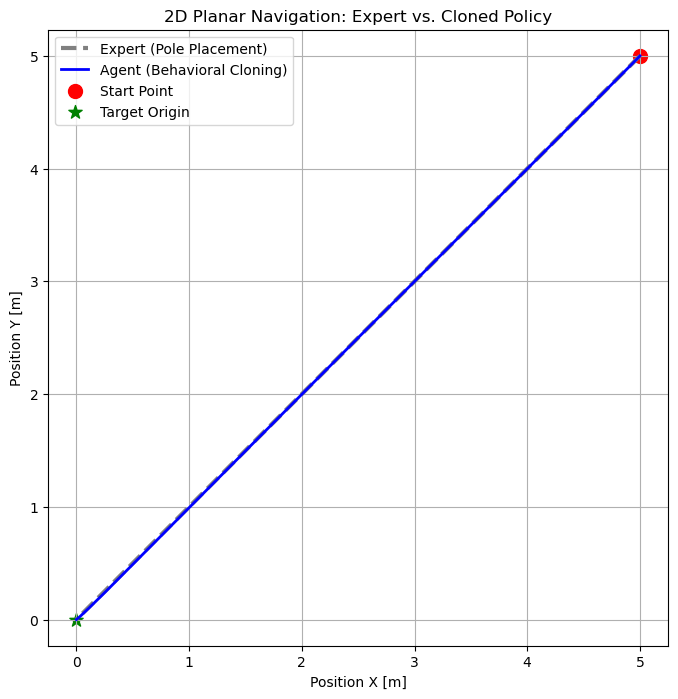

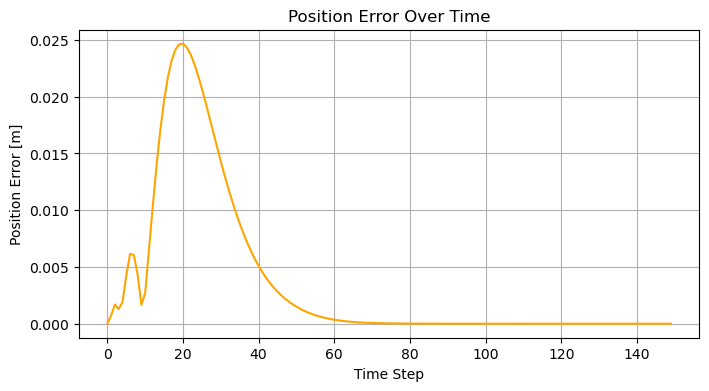

In [6]:
sim_steps = 150
# Initial state: x0 = [p_x0, p_y0, v_x0, v_y0]^T
# Start at a position [5.0, 5.0] with zero velocity
x0 = np.array([5.0, 5.0, 0.0, 0.0])

# Pre-allocate trajectory buffers for plotting
traj_expert_pos = np.zeros((sim_steps, 2))
traj_agent_pos = np.zeros((sim_steps, 2))

x_exp = x0.copy()
x_agt = x0.copy()

policy.eval()

with torch.no_grad():
    for k in range(sim_steps):
        # Store positions
        traj_expert_pos[k, :] = x_exp[0:2]
        traj_agent_pos[k, :] = x_agt[0:2]
        
        # Expert action (deterministic analytical law)
        u_exp = -K_expert_np @ x_exp
        
        # Agent action (neural network inference)
        x_agt_tensor = torch.tensor(x_agt, dtype=torch.float32).unsqueeze(0)
        u_agt = policy(x_agt_tensor).numpy().flatten()
        
        # Environment step (Linear dynamics)
        x_exp = A @ x_exp + B @ u_exp
        x_agt = A @ x_agt + B @ u_agt

# ============================================================================
# 6. VISUALIZATION (2D Trajectory)
# ============================================================================
plt.figure(figsize=(8, 8))
plt.plot(traj_expert_pos[:, 0], traj_expert_pos[:, 1], 
         label='Expert (Pole Placement)', linewidth=3, linestyle='--', color='gray')
plt.plot(traj_agent_pos[:, 0], traj_agent_pos[:, 1], 
         label='Agent (Behavioral Cloning)', linewidth=2, color='blue')

# Plot start and target points
plt.scatter(x0[0], x0[1], color='red', s=100, label='Start Point')
plt.scatter(0, 0, color='green', s=100, marker='*', label='Target Origin')

plt.title('2D Planar Navigation: Expert vs. Cloned Policy')
plt.xlabel('Position X [m]')
plt.ylabel('Position Y [m]')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

pos_error_agent = np.linalg.norm(traj_expert_pos - traj_agent_pos, axis=1)
plt.figure(figsize=(8, 4))
plt.plot(pos_error_agent, label='Position Error (Agent vs Expert)', color='orange')
plt.title('Position Error Over Time')
plt.xlabel('Time Step')
plt.ylabel('Position Error [m]')
plt.grid(True)
plt.show()